# Analysis of theta metrics (peak frequency, theta-running coupling)


In [5]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr 
from matplotlib.lines import Line2D

from figure_style import apply_style, set_panel_title, WT, NLGF
GENO_COLORS = {"NLGF": NLGF, "WT": WT}
GENO_ORDER = ["WT", "NLGF"]
apply_style()

In [6]:
# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv' 
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / 'LFP_analysis' / 'theta_metrics'
os.makedirs(OUTPUT_DIR, exist_ok=True)


df = pd.read_csv(LFP_CSV_PATH)

# Clean names / categorical order
df["Genotype"] = pd.Categorical(df["Genotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)


## Step 1 — Normality (Shapiro–Wilk) and Step 2 — Levene's test, per metric × environment

In [7]:
# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
    "theta_running_stderr": "Theta–running standard error",
    "theta_running_intercept_stderr": "Theta–running intercept standard error",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}

# ─── Step 1: Normality (Shapiro-Wilk) + Step 2: Levene's test, per metric × environment ──
# Tested on per-animal means (one value per mouse per environment), so a mouse
# contributing more than one session row doesn't pseudoreplicate the test — see
# Section 5 of CLAUDE.md. Both genotype groups must pass Shapiro (p > 0.05, n >= 3)
# for the metric × environment combination to be treated as normal. Levene's center
# is 'mean' (classic Levene) when normal, 'median' (Brown-Forsythe, robust to
# non-normality) otherwise. Both decisions drive the primary test choice in the
# next cell.
from scipy.stats import shapiro, levene

animal_agg_store  = {}   # (metric, environment) -> per-animal mean/median dataframe
normality_results = {}   # (metric, environment) -> bool (True = both genotypes normal)
levene_results    = {}   # (metric, environment) -> dict(statistic, p_value, center, equal_var)
diag_rows = []

for metric in metrics:
    for env in sorted(df["environment"].dropna().astype(str).unique()):
        sub = df.loc[df["environment"].astype(str) == env]
        if sub.empty:
            continue

        animal_df = (
            sub.groupby(["mouse_name", "Genotype"], observed=True)[metric]
            .agg(metric_mean="mean", metric_median="median", n_sessions="count")
            .reset_index()
        )
        animal_agg_store[(metric, env)] = animal_df

        shapiro_p = {}
        is_normal = True
        for geno in GENO_ORDER:
            vals = animal_df.loc[animal_df["Genotype"].astype(str) == geno, "metric_mean"].dropna().values
            if len(vals) < 3:
                is_normal = False
                shapiro_p[geno] = np.nan
            else:
                _, sw_p = shapiro(vals)
                shapiro_p[geno] = sw_p
                if sw_p <= 0.05:
                    is_normal = False
        normality_results[(metric, env)] = is_normal

        wt_vals   = animal_df.loc[animal_df["Genotype"].astype(str) == "WT",   "metric_mean"].dropna().values
        nlgf_vals = animal_df.loc[animal_df["Genotype"].astype(str) == "NLGF", "metric_mean"].dropna().values

        center = "mean" if is_normal else "median"
        if len(wt_vals) >= 2 and len(nlgf_vals) >= 2:
            lev_stat, lev_p = levene(wt_vals, nlgf_vals, center=center)
            equal_var = lev_p > 0.05
        else:
            lev_stat, lev_p, equal_var = np.nan, np.nan, np.nan
        levene_results[(metric, env)] = {
            "statistic": lev_stat, "p_value": lev_p,
            "center": center, "equal_var": equal_var,
        }

        diag_rows.append({
            "metric": metric, "environment": env,
            "n_WT_mice": len(wt_vals), "n_NLGF_mice": len(nlgf_vals),
            "shapiro_p_WT": shapiro_p.get("WT", np.nan),
            "shapiro_p_NLGF": shapiro_p.get("NLGF", np.nan),
            "normal": is_normal,
            "levene_center": center, "levene_stat": lev_stat, "levene_p": lev_p,
            "equal_var": equal_var,
        })

diagnostics_df = pd.DataFrame(diag_rows)
print(diagnostics_df.to_string(index=False))

                        metric  environment  n_WT_mice  n_NLGF_mice  shapiro_p_WT  shapiro_p_NLGF  normal levene_center  levene_stat  levene_p  equal_var
                max_theta_freq linear_track          8            9      0.249453        0.088650    True          mean     0.150893  0.703141       True
                max_theta_freq   open_field          8            9      0.303635        0.720703    True          mean     0.024953  0.876592       True
           theta_running_slope linear_track          8            8      0.664233        0.126505    True          mean     4.427453  0.053917       True
           theta_running_slope   open_field          8            9      0.009233        0.525966   False        median     0.036124  0.851807       True
       theta_running_intercept linear_track          8            8      0.548081        0.260865    True          mean     0.819782  0.380562       True
       theta_running_intercept   open_field          8            9      0.7

## Step 3 — Primary statistical test (Student's/Welch's t-test if normal, Mann-Whitney U otherwise), with BH-FDR correction

In [8]:
"""
Primary statistical test per metric × environment, chosen from the previous
cell's Shapiro (normality) and Levene's (variance-homogeneity) results:
  - normal combination  -> t-test on per-animal means (Student's if Levene's
    equal_var is True, Welch's otherwise)
  - non-normal combination -> Mann-Whitney U on per-animal medians
Benjamini-Hochberg FDR correction is then applied across all metric x
environment tests run in this cell (one family — these are all "is there a
genotype difference in this PAC/theta metric" questions, unlike the separate,
narrower FDR correction applied later to the GLMM-TMB vs secondary-test
concordance subset).
Saves:
  lfp_stats_outputs/
    primary_test_results.csv
    primary_test_results.html
"""

import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML


def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


test_results = []

for metric in metrics:
    for env in sorted(df["environment"].dropna().astype(str).unique()):
        key = (metric, env)
        if key not in animal_agg_store:
            continue

        animal_df = animal_agg_store[key]
        is_normal = normality_results[key]

        if is_normal:
            value_col = "metric_mean"
            equal_var = levene_results[key]["equal_var"]
            wt_vals   = animal_df.loc[animal_df["Genotype"].astype(str) == "WT",   value_col].dropna().values
            nlgf_vals = animal_df.loc[animal_df["Genotype"].astype(str) == "NLGF", value_col].dropna().values
            if len(wt_vals) < 2 or len(nlgf_vals) < 2:
                continue
            stat, p_val = ttest_ind(wt_vals, nlgf_vals, equal_var=bool(equal_var))
            test_name = "Student's t-test" if equal_var else "Welch's t-test"
        else:
            value_col = "metric_median"
            wt_vals   = animal_df.loc[animal_df["Genotype"].astype(str) == "WT",   value_col].dropna().values
            nlgf_vals = animal_df.loc[animal_df["Genotype"].astype(str) == "NLGF", value_col].dropna().values
            if len(wt_vals) < 1 or len(nlgf_vals) < 1:
                continue
            stat, p_val = mannwhitneyu(wt_vals, nlgf_vals, alternative="two-sided")
            test_name = "Mann-Whitney U"

        test_results.append({
            "metric": metric, "environment": env,
            "test": test_name, "value_col": value_col,
            "statistic": stat, "pvalue": p_val,
            "n_WT": len(wt_vals), "n_NLGF": len(nlgf_vals),
            "WT_value":   np.mean(wt_vals)   if is_normal else np.median(wt_vals),
            "NLGF_value": np.mean(nlgf_vals) if is_normal else np.median(nlgf_vals),
            "stars": _pstars(p_val),
        })

test_results_df = pd.DataFrame(test_results)

# ── Benjamini-Hochberg FDR correction across all metric x environment tests ────
ALPHA = 0.05
valid_p = test_results_df["pvalue"].notna()
test_results_df["pvalue_fdr"] = np.nan
test_results_df.loc[valid_p, "pvalue_fdr"] = multipletests(
    test_results_df.loc[valid_p, "pvalue"], method="fdr_bh"
)[1]
test_results_df["significant_fdr"] = test_results_df["pvalue_fdr"] < ALPHA
test_results_df["stars_fdr"] = test_results_df["pvalue_fdr"].apply(_pstars)

test_results_df.to_csv(os.path.join(OUTPUT_DIR, "primary_test_results.csv"), index=False)


def _colour_pval(p):
    if pd.isna(p): return ""
    if p < 0.001: return "background-color: #c62828; color: white; font-weight: bold;"
    if p < 0.01:  return "background-color: #ef5350; color: white; font-weight: bold;"
    if p < 0.05:  return "background-color: #ffcc80; color: black; font-weight: bold;"
    return ""


styled = (test_results_df.style
          .applymap(_colour_pval, subset=["pvalue", "pvalue_fdr"])
          .format({"statistic": "{:.4f}", "pvalue": "{:.4f}", "pvalue_fdr": "{:.4f}",
                   "WT_value": "{:.4f}", "NLGF_value": "{:.4f}"}))

display(HTML("<h3>Primary statistical test per metric × environment "
             "(t-test if normal, Mann-Whitney U otherwise), "
             "raw and Benjamini-Hochberg FDR-corrected p-values</h3>"))
display(styled)

html_path = os.path.join(OUTPUT_DIR, "primary_test_results.html")
with open(html_path, "w") as f:
    f.write(styled.to_html())

n_sig_raw = int(test_results_df["pvalue"].lt(ALPHA).sum())
n_sig_fdr = int(test_results_df["significant_fdr"].sum())
print(f"Significant at raw p<0.05: {n_sig_raw}/{len(test_results_df)}; "
      f"significant after BH-FDR: {n_sig_fdr}/{len(test_results_df)}")
print(f"✅ Primary test results saved to: {os.path.join(OUTPUT_DIR, 'primary_test_results.csv')}")
print(f"✅ HTML visualisation saved to: {html_path}")

/var/folders/7r/v13tprj17p5fvy167bbhtmch0000gn/T/ipykernel_37739/3524668634.py:97: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_colour_pval, subset=["pvalue", "pvalue_fdr"])


,metric,environment,test,value_col,statistic,pvalue,n_WT,n_NLGF,WT_value,NLGF_value,stars,pvalue_fdr,significant_fdr,stars_fdr
0,max_theta_freq,linear_track,Student's t-test,metric_mean,4.9200,0.0002,8,9,8.1710,7.4291,***,0.0006,True,***
1,max_theta_freq,open_field,Student's t-test,metric_mean,6.9347,0.0000,8,9,8.1973,7.5819,***,0.0001,True,***
2,theta_running_slope,linear_track,Student's t-test,metric_mean,3.6308,0.0027,8,8,0.0079,-0.0187,**,0.0055,True,**
3,theta_running_slope,open_field,Mann-Whitney U,metric_median,71.0000,0.0002,8,9,0.0160,-0.0088,***,0.0006,True,***
4,theta_running_intercept,linear_track,Student's t-test,metric_mean,2.3303,0.0353,8,8,8.3072,8.1154,*,0.0604,False,ns
5,theta_running_intercept,open_field,Student's t-test,metric_mean,1.6244,0.1251,8,9,8.1981,8.0224,ns,0.1668,False,ns
6,theta_running_rvalue,linear_track,Welch's t-test,metric_mean,4.5451,0.0007,8,8,0.0461,-0.0964,***,0.0017,True,**
7,theta_running_rvalue,open_field,Student's t-test,metric_mean,4.9291,0.0002,8,9,0.0884,-0.0329,***,0.0006,True,***
8,theta_running_stderr,linear_track,Mann-Whitney U,metric_median,37.0000,0.6454,8,8,0.0003,0.0003,ns,0.6454,False,ns
9,theta_running_stderr,open_field,Mann-Whitney U,metric_median,45.0000,0.4234,8,9,0.0003,0.0003,ns,0.4722,False,ns


Significant at raw p<0.05: 7/12; significant after BH-FDR: 6/12
✅ Primary test results saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/theta_metrics/primary_test_results.csv
✅ HTML visualisation saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/theta_metrics/primary_test_results.html


## Plot the same graphs, sharing the y-axis for the 2 environments, annotated with the Step 3 primary test, with box plots overlaid on the per-animal points

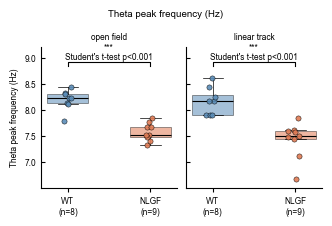

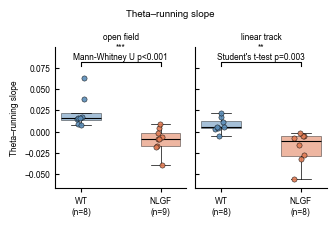

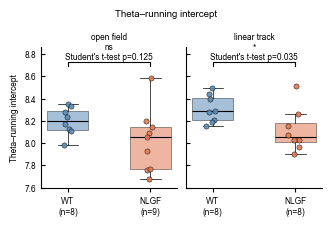

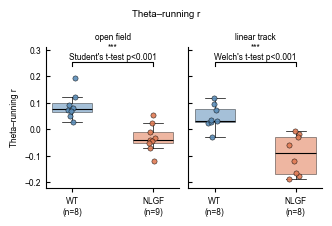

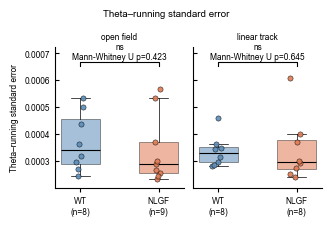

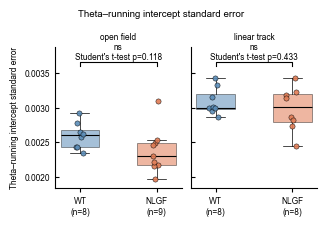

Done.
Saved shared y-axis plots to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/theta_metrics/shared_yaxis_primary_test_plots


In [9]:
# Shared y-axis plots for PAC comodulogram metrics, plotted at the same
# per-animal level Step 3 tested on, and annotated with whichever test Step 3
# selected for that metric × environment. Each genotype gets a box plot
# (median/IQR, no fliers) with jittered per-animal points on top — same
# box+scatter style as the spike_width/kl_spatial_sparsity/etc. plots in the
# open field and linear track notebooks (Step 4).
# Run after the Step 1-3 cells above, where df, metrics, animal_agg_store and
# test_results_df are defined.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SHARED_Y_OUTDIR = os.path.join(OUTPUT_DIR, "shared_yaxis_primary_test_plots")
os.makedirs(SHARED_Y_OUTDIR, exist_ok=True)

# Put open field first, linear track second if both exist
preferred_env_order = ["open_field", "linear_track"]
envs_present = list(df["environment"].dropna().astype(str).unique())
envs = [e for e in preferred_env_order if e in envs_present]
envs += [e for e in sorted(envs_present) if e not in envs]


def _clean_name(x):
    return str(x).replace("/", "_").replace(" ", "_")


def _ptext(test_name, p):
    if pd.isna(p):
        return f"{test_name} p=n/a"
    if p < 0.001:
        return f"{test_name} p<0.001"
    return f"{test_name} p={p:.3f}"


def plot_metric_shared_yaxis(metric, ylabel, save=True):
    envs_for_metric = [e for e in envs if (metric, e) in animal_agg_store]
    if not envs_for_metric:
        return

    # shared y-range across environments, computed on the value each test used
    all_vals = []
    for env in envs_for_metric:
        row = test_results_df[(test_results_df["metric"] == metric) &
                               (test_results_df["environment"] == env)]
        if row.empty:
            continue
        value_col = row.iloc[0]["value_col"]
        all_vals.append(animal_agg_store[(metric, env)][value_col].dropna().values)
    if not all_vals:
        return
    y_all = np.concatenate(all_vals)
    ymin, ymax = np.nanmin(y_all), np.nanmax(y_all)
    yrng = ymax - ymin if ymax > ymin else max(abs(ymax), 1.0) * 0.1

    y_bracket = ymax + 0.12 * yrng
    h_bracket = 0.04 * yrng
    y_upper = ymax + 0.30 * yrng
    y_lower = ymin - 0.08 * yrng

    fig, axes = plt.subplots(
        1, len(envs_for_metric),
        figsize=(1.65 * len(envs_for_metric), 2.2),
        sharey=True
    )
    if len(envs_for_metric) == 1:
        axes = [axes]

    rng = np.random.default_rng(10)

    for ax, env in zip(axes, envs_for_metric):
        row = test_results_df[(test_results_df["metric"] == metric) &
                               (test_results_df["environment"] == env)]
        if row.empty:
            ax.set_visible(False)
            continue
        row = row.iloc[0]
        value_col = row["value_col"]
        test_name = row["test"]

        animal_df = animal_agg_store[(metric, env)]
        genos = [g for g in GENO_ORDER if g in animal_df["Genotype"].astype(str).values]
        vals = {
            g: animal_df.loc[animal_df["Genotype"].astype(str) == g, value_col].dropna().values
            for g in genos
        }

        # Box plots per genotype (median/IQR, no fliers), same style as the
        # Step 4 box+scatter plots for spike_width/kl_spatial_sparsity/etc.
        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue
            bp_parts = ax.boxplot(
                vals[g], positions=[xi], widths=0.5,
                patch_artist=True, manage_ticks=False,
                showfliers=False,
                boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
                              alpha=0.55, linewidth=0.5),
                medianprops=dict(color="black", linewidth=0.8),
                whiskerprops=dict(linewidth=0.5),
                capprops=dict(linewidth=0.5),
                zorder=7,
            )
            bp_parts["medians"][0].set_zorder(8)

        # Individual animal points
        for xi, g in enumerate(genos):
            y = vals[g]
            jitter = rng.normal(0, 0.045, size=len(y))
            ax.scatter(
                np.full(len(y), xi) + jitter, y,
                s=14, color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black", linewidth=0.35, alpha=0.9, zorder=10,
            )

        # Primary-test annotation
        if len(genos) >= 2:
            p = row["pvalue"]
            stars = row["stars"]
            label = f"{stars}\n{_ptext(test_name, p)}"

            ax.plot([0, 0, 1, 1],
                    [y_bracket, y_bracket + h_bracket,
                     y_bracket + h_bracket, y_bracket],
                    color="black", linewidth=0.8, clip_on=False)
            ax.text(0.5, y_bracket + h_bracket, label,
                    ha="center", va="bottom", fontsize=6)

        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos])
        ax.set_title(env.replace("_", " "))
        ax.set_ylim(y_lower, y_upper)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(ylabel)
    for ax in axes[1:]:
        ax.set_ylabel("")

    fig.suptitle(ylabel, fontsize=7)
    fig.tight_layout()

    if save:
        fig.savefig(
            os.path.join(
                SHARED_Y_OUTDIR,
                f"{_clean_name(metric)}_openfield_lineartrack_shared_yaxis_primary_test.pdf"
            )
        )

    plt.show()
    plt.close(fig)


for metric, ylabel in metrics.items():
    plot_metric_shared_yaxis(metric, ylabel)

print("Done.")
print(f"Saved shared y-axis plots to: {SHARED_Y_OUTDIR}")